First 5 rows of dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Column Names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 e

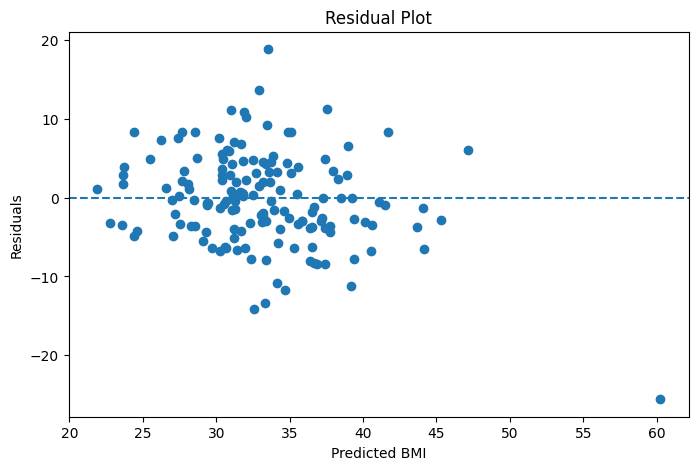

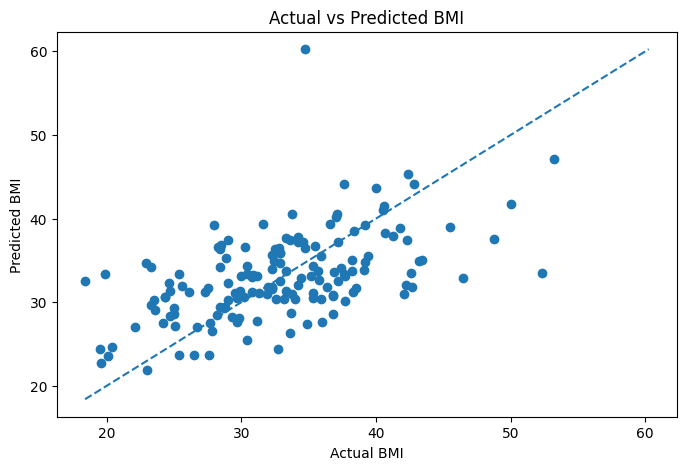

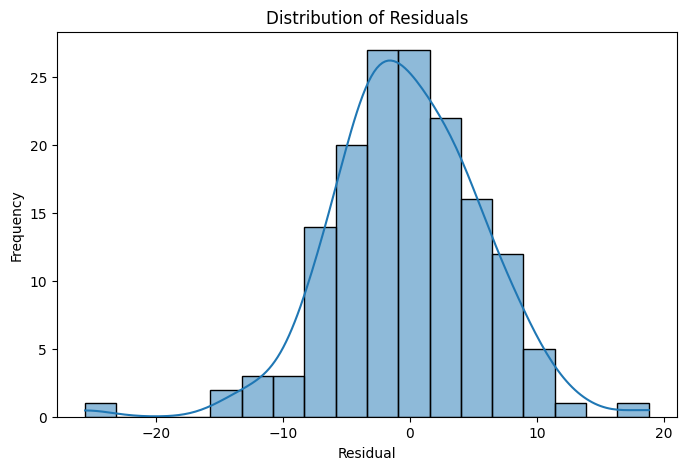

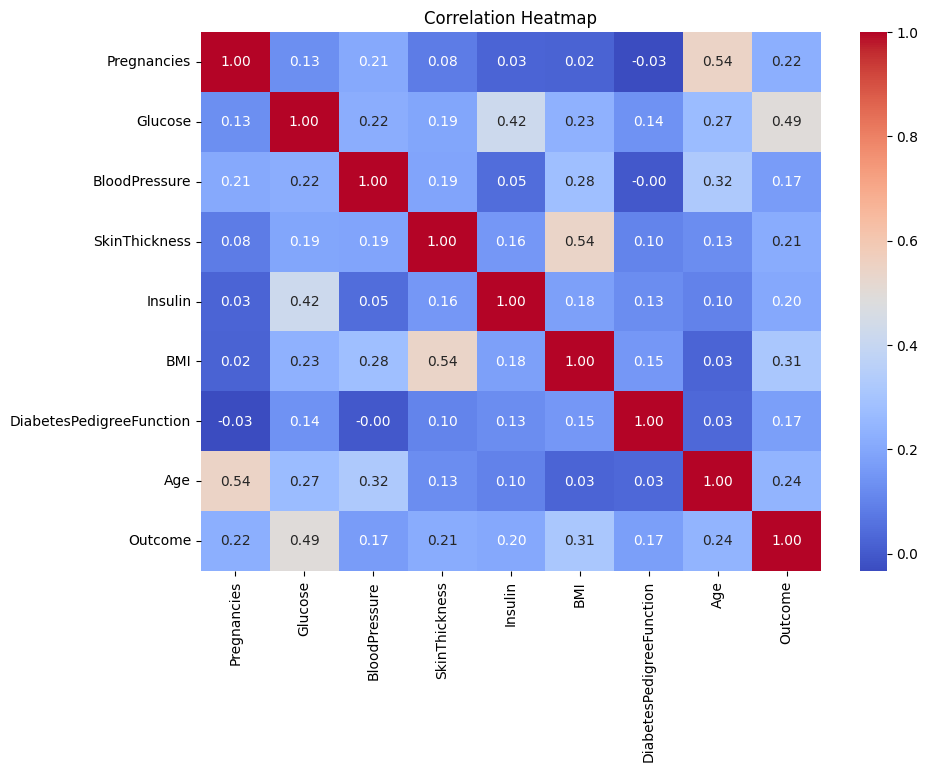


========== FINAL RESULT ==========
Target Variable: BMI
Regression Model: Multiple Linear Regression
MAE  : 4.4753
MSE  : 33.9171
RMSE : 5.8238
R²   : 0.2245


In [4]:
# ============================================================
# EXPERIMENT: Regression on Pima Indians Diabetes Dataset
# Target Variable: BMI
# ============================================================

# 1. Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 2. Load the Dataset
# ------------------------------------------------------------

df = pd.read_csv("/content/sample_data/diabetes.csv")

# Display first 5 rows
print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

# ------------------------------------------------------------
# 3. Check Dataset Information
# ------------------------------------------------------------

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ------------------------------------------------------------
# 4. Handle Invalid Values
# ------------------------------------------------------------

# In this dataset, these columns should not normally contain 0.
# Replace 0 with NaN for preprocessing.

invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[invalid_columns] = df[invalid_columns].replace(0, np.nan)

print("\nMissing/Invalid values after replacement:")
print(df.isnull().sum())

# Fill missing values using median
for column in invalid_columns:
    df[column] = df[column].fillna(df[column].median())

print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 5. Select Features and Target
# ------------------------------------------------------------

# BMI is the continuous target variable
X = df[
    [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "DiabetesPedigreeFunction",
        "Age",
        "Outcome"
    ]
]

y = df["BMI"]

print("\nFeatures:")
print(X.head())

print("\nTarget (BMI):")
print(y.head())

# ------------------------------------------------------------
# 6. Split Dataset into Training and Testing Sets
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ------------------------------------------------------------
# 7. Create Linear Regression Model
# ------------------------------------------------------------

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("\nModel training completed.")

# ------------------------------------------------------------
# 8. Display Model Coefficients
# ------------------------------------------------------------

print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

# ------------------------------------------------------------
# 9. Generate Predictions
# ------------------------------------------------------------

y_pred = model.predict(X_test)

print("\nActual vs Predicted BMI:")
comparison = pd.DataFrame({
    "Actual BMI": y_test.values,
    "Predicted BMI": y_pred
})

print(comparison.head(10))

# ------------------------------------------------------------
# 10. Evaluate Model Performance
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

# ------------------------------------------------------------
# 11. Residual Calculation
# ------------------------------------------------------------

residuals = y_test - y_pred

print("\nFirst 10 Residuals:")
print(residuals.head(10))

# ------------------------------------------------------------
# 12. Residual Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted BMI")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# ------------------------------------------------------------
# 13. Actual vs Predicted Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

# Reference line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs Predicted BMI")

plt.show()

# ------------------------------------------------------------
# 14. Distribution of Residuals
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

# ------------------------------------------------------------
# 15. Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# ------------------------------------------------------------
# 16. Final Result
# ------------------------------------------------------------

print("\n========== FINAL RESULT ==========")
print("Target Variable: BMI")
print("Regression Model: Multiple Linear Regression")
print("MAE  :", round(mae, 4))
print("MSE  :", round(mse, 4))
print("RMSE :", round(rmse, 4))
print("R²   :", round(r2, 4))